# STEP 1 — Load & Transform Dataset

## Imports

In [188]:
import nltk
import re
import json
import os
import numpy as np
import pandas as pd
import torch
from nltk.corpus import stopwords
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Concatenate
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense, Bidirectional, Dropout
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Activation, RepeatVector, Lambda
# nltk.download('punkt')
# nltk.download('punkt_tab')
# nltk.download('stopwords')

## Parse JSON Files

In [189]:
def load_dataset(path):
    dataset = []
    
    for file in os.listdir(path):
        if file.endswith(".json"):
            file_path = os.path.join(path, file)
            
            with open(file_path, encoding="utf-8") as f:
                data = json.load(f)

                for article in data.get("data", []):
                    for para in article.get("paragraphs", []):
                        context = para.get("context", "")

                        for qa in para.get("qas", []):
                            question = qa.get("question", "")
                            answers = qa.get("answers", [])

                            if answers:
                                answer = answers[0].get("text", "")
                                
                                dataset.append({
                                    "question": question,
                                    "context": context,
                                    "answer": answer
                                })
    
    return dataset
    

## Inspect Data

In [190]:
data = load_dataset("data")

print(f"\nTotal examples loaded: {len(data)}")
if data:
    print("\nFirst example:")
    print(json.dumps(data[0], indent=2, ensure_ascii=False))


Total examples loaded: 240

First example:
{
  "question": "ما الحدث الذي جعل أورسون ويلز مشهورًا قبل دخوله السينما؟",
  "context": "في ليلة 30 أكتوبر 1938، انقطع بث إذاعي ليعلن عن غزو فضائي في نيوجيرسي. تسبب ذلك في ذعر واسع لأن الناس صدقوا الخبر. لاحقًا تبيّن أن الحدث كان تمثيلية إذاعية من إخراج أورسون ويلز. هذه التجربة أثبتت قدرته على التأثير في الجمهور.",
  "answer": "تمثيلية إذاعية عن غزو فضائي"
}


# STEP 2 — Preprocessing

## Cleaning

In [191]:
# def remove_stopwords_and_punctuation_from_text(text):
#     nltk_stop_words = set(stopwords.words('arabic'))


#     # punctuation ='!"$%&()*,-./:;<=>?@[\\]^_`{|}~'
#     punctuation = [
#     "،","؛","؟","ـ","«","»","‹","›","“","”","‘","’",
#     ".",",",";",":","!","?","-","_","(",")","[","]","{","}",
#     "\"","'","/","\\","|","@","#","$","%","^","&","*","+","=","<",">","~","`","``","''"
#     ]
#     for p in punctuation:
#         text = text.replace(p, '')

#     tokens = nltk.word_tokenize(text)

#     filtered_tokens = [
#         word for word in tokens 
#         if word not in nltk_stop_words 
#         and not re.search(r'[a-zA-Z]', word)]   # remove words containing English letters
#     # Join the tokens back into a string
#     filtered_text = ' '.join(filtered_tokens)
#     return filtered_text

In [192]:
# for item in data:
#     item['question'] = remove_stopwords_and_punctuation_from_text(item['question'])
#     item['context'] = remove_stopwords_and_punctuation_from_text(item['context'])
#     item['answer'] = remove_stopwords_and_punctuation_from_text(item['answer'])

## Normalization

In [193]:
def normalize_text(text):
    
    # 1. Convert English letters to lowercase
    text = text.lower()
    
    # 2. Remove Arabic Tashkeel (diacritics)
    tashkeel = r'[\u0617-\u061A\u064B-\u0652]'
    text = re.sub(tashkeel, '', text)

    # 3. Normalize Arabic letters
    text = re.sub("[إأآا]", "ا", text)
    text = re.sub("ى", "ي", text)
    text = re.sub("ة", "ه", text)
    text = re.sub("گ", "ك", text)

    # 4. Remove Tatweel (ـ)
    text = re.sub("ـ", "", text)

    return text

In [194]:
for item in data:
    item['question'] = normalize_text(item['question'])
    item['context'] = normalize_text(item['context'])
    item['answer'] = normalize_text(item['answer'])

# STEP 3 — Tokenization

## Tokenize

### Approach 1

In [195]:
# def tokenize(text):
#     return text.split()

### Approach 2

In [196]:
tokenizer = Tokenizer(
    num_words=2390,
    split=' ',
    char_level=False,
    oov_token="<OOV>"
  )

In [197]:
all_texts = []

for item in data:
    all_texts.append(item['question'])
    all_texts.append(item['context'])
    all_texts.append(item['answer'])

all_texts = [text for text in all_texts if text and isinstance(text, str)]
tokenizer.fit_on_texts(all_texts)

In [198]:
vocab_list = tokenizer.word_index
print(len(vocab_list))

2381


## Encode Text

### Approach 1

In [199]:
# def encode(text, vocab, max_len=100):
#     tokens = tokenize(text)
#     ids = [vocab.get(t, vocab["<unk>"]) for t in tokens]

#     # padding
#     ids = ids[:max_len]
#     ids += [vocab["<pad>"]] * (max_len - len(ids))

#     return ids

In [200]:
# ### Encode the dataset with answers also encoded
# encoded_data = []
# for item in data:
#     encoded_item = {
#         "question": encode(item["question"], vocab),
#         "context": encode(item["context"], vocab),
#         "answer": encode(item["answer"], vocab)
#     }
#     encoded_data.append(encoded_item)


### Approach 2

In [201]:
# max_question_len = 0
# max_context_len = 0
# max_answer_len = 0

# for item in data:
#     q_tokens = len(tokenizer.texts_to_sequences([item['question']])[0]) if 'question' in item else 0
#     c_tokens = len(tokenizer.texts_to_sequences([item['context']])[0])  if 'context' in item else 0
#     a_tokens = len(tokenizer.texts_to_sequences([item['answer']])[0])    if 'answer' in item else 0
    
#     max_question_len = max(max_question_len, q_tokens)
#     max_context_len  = max(max_context_len, c_tokens)
#     max_answer_len   = max(max_answer_len, a_tokens)

# print(f"Maximum Question Length: {max_question_len} tokens")
# print(f"Maximum Context Length : {max_context_len} tokens")
# print(f"Maximum Answer Length  : {max_answer_len} tokens")

In [202]:
lengths = [len(item['question']) for item in data]
print("input_sequences lengths:")
print("max:", np.max(lengths))
print("min:", np.min(lengths))
print("95 percentile:", np.percentile(lengths,95))
print("90 percentile:", np.percentile(lengths,90))

lengths = [len(item['answer']) for item in data]
print("answer_sequences lengths:")
print("max:", np.max(lengths))
print("min:", np.min(lengths))
print("95 percentile:", np.percentile(lengths,95))
print("90 percentile:", np.percentile(lengths,90))

lengths = [len(item['context']) for item in data]
print("context_sequences lengths:")
print("max:", np.max(lengths))
print("min:", np.min(lengths))
print("95 percentile:", np.percentile(lengths,95))
print("90 percentile:", np.percentile(lengths,90))

input_sequences lengths:
max: 73
min: 14
95 percentile: 59.0
90 percentile: 54.099999999999994
answer_sequences lengths:
max: 66
min: 4
95 percentile: 50.0
90 percentile: 45.0
context_sequences lengths:
max: 261
min: 16
95 percentile: 169.04999999999998
90 percentile: 135.2


In [203]:
MAX_Q_LEN = 100
MAX_C_LEN = 200
MAX_A_LEN = 70

q_seq = []
c_seq = []
a_seq = []

for item in data:
    q_seq.append(tokenizer.texts_to_sequences([item['question']])[0])
    c_seq.append(tokenizer.texts_to_sequences([item['context']])[0])
    a_seq.append(tokenizer.texts_to_sequences([item['answer']])[0])

q_seq = pad_sequences(q_seq, maxlen=MAX_Q_LEN, padding='post')
c_seq = pad_sequences(c_seq, maxlen=MAX_C_LEN, padding='post')
a_seq = pad_sequences(a_seq, maxlen=MAX_A_LEN, padding='post')

In [204]:
max(len(seq) for seq in a_seq)

70

## Build Vocabulary

### Approach 1

In [205]:
# from collections import Counter

# def build_vocab(data, min_freq=2):
#     counter = Counter()

#     for item in data:
#         counter.update(tokenize(item["question"]))
#         counter.update(tokenize(item["context"]))

#     vocab = {"<pad>": 0, "<unk>": 1}

#     for word, freq in counter.items():
#         if freq >= min_freq:
#             vocab[word] = len(vocab)

#     return vocab

In [206]:
# vocab = build_vocab(data)
# print(f"Vocabulary size: {len(vocab)}")

### Approach 2

In [207]:
# use this to get insight on the Tokenizer
word_index = tokenizer.word_index
vocab_size = len(word_index) + 1

## PyTorch Dataset

In [208]:
q_tensor = torch.tensor(q_seq, dtype=torch.long)
c_tensor = torch.tensor(c_seq, dtype=torch.long)
a_tensor = torch.tensor(a_seq, dtype=torch.long)

In [209]:
from torch.utils.data import Dataset

class QADataset(Dataset):
    def __init__(self, q, c, a):
        self.q = q
        self.c = c
        self.a = a

    def __len__(self):
        return len(self.q)

    def __getitem__(self, idx):
        return self.q[idx], self.c[idx], self.a[idx]

## DataLoader

In [210]:
from torch.utils.data import DataLoader

dataset = QADataset(q_tensor, c_tensor, a_tensor)
loader = DataLoader(dataset, batch_size=32, shuffle=True)

# Bi-LSTM Model

## Approach 1

In [211]:
import torch.nn as nn

class RNN_QA_Model(nn.Module):
    def __init__(self, vocab_size, max_a_len, embed_dim=128, hidden_dim=256):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)

        self.q_lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.c_lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True, bidirectional=True)

        self.fc = nn.Linear(hidden_dim * 4, hidden_dim)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.5)
        self.out = nn.Linear(hidden_dim, max_a_len * vocab_size)

        self.max_a_len = max_a_len
        self.vocab_size = vocab_size

    def encode(self, x, lstm):
        emb = self.embedding(x)
        _, (h, _) = lstm(emb)

        h = torch.cat((h[-2], h[-1]), dim=1)
        return h

    def forward(self, q, c):
        q_repr = self.encode(q, self.q_lstm)
        c_repr = self.encode(c, self.c_lstm)

        fused = torch.cat([q_repr, c_repr], dim=1)

        hidden = self.fc(fused)
        hidden = self.relu(hidden)
        hidden = self.dropout(hidden)
        logits = self.out(hidden)
        return logits.view(-1, self.max_a_len, self.vocab_size)

In [212]:
import torch.optim as optim

model = RNN_QA_Model(vocab_size, max_a_len=MAX_A_LEN)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss(ignore_index=0)

In [213]:
def train(model, loader, epochs=10):
    model.train()

    for epoch in range(epochs):
        total_loss = 0

        for q, c, a in loader:
            optimizer.zero_grad()

            logits = model(q, c)  # (batch, MAX_A_LEN, vocab_size)

            loss = criterion(
                logits.reshape(-1, logits.size(-1)),
                a.reshape(-1).long()
            )

            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(f"Epoch {epoch}: {total_loss:.4f}")

In [214]:
train(model, loader)

Epoch 0: 62.1274
Epoch 1: 58.3626
Epoch 2: 48.4596
Epoch 3: 42.7703
Epoch 4: 38.1693
Epoch 5: 35.9389
Epoch 6: 33.0183
Epoch 7: 30.9325
Epoch 8: 27.7850
Epoch 9: 27.1777


In [215]:
def accuracy(model, loader):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for q, c, a in loader:
            logits = model(q, c)
            pred = logits.argmax(dim=2)

            mask = (a != 0)
            correct += ((pred == a) & mask).sum().item()
            total += mask.sum().item()

    return correct / total if total > 0 else 0.0

In [216]:
accuracy(model, loader)

0.4016877637130802

In [217]:
def get_arabic_example_from_file(file_path='data/citizen_kane_qa_dataset.json'):
    try:
        with open(file_path, encoding='utf-8') as f:
            content = json.load(f)

        paragraph = content['data'][0]['paragraphs'][0]
        context = paragraph['context']
        question = paragraph['qas'][0]['question']
        answer = paragraph['qas'][0]['answers'][0]['text']
        return context, question, answer
    except Exception as e:
        print('تعذر تحميل مثال من الملف:', e)
        return None, None, None

In [218]:
def predict(model, question, context):
    model.eval()

    q = tokenizer.texts_to_sequences([question])
    c = tokenizer.texts_to_sequences([context])

    q = pad_sequences(q, maxlen=MAX_Q_LEN)
    c = pad_sequences(c, maxlen=MAX_C_LEN)

    q = torch.tensor(q, dtype=torch.long)
    c = torch.tensor(c, dtype=torch.long)

    with torch.no_grad():
        logits = model(q, c)
        pred_ids = logits.argmax(dim=2).squeeze(0).tolist()

    words = [tokenizer.index_word.get(idx, "<OOV>") for idx in pred_ids if idx != 0]
    return " ".join(words).strip()

In [219]:
predict(model,'ما الحدث الذي جعل أورسون ويلز مشهورًا قبل دخوله السينما؟', 'في ليلة 30 أكتوبر 1938، انقطع بث إذاعي ليعلن عن غزو فضائي في نيوجيرسي. تسبب ذلك في ذعر واسع لأن الناس صدقوا الخبر. لاحقًا تبيّن أن الحدث كان تمثيلية إذاعية من إخراج أورسون ويلز. هذه التجربة أثبتت قدرته على التأثير في الجمهور.')

'في الي في في في تكساس الزلازل الماء كعنصر اساسي من الفضاء والبقاء الحركه السعاده ابداعيا ومانك مشروع قديما؟ بيوصلوا وتحول ويخش حولنا الطائره؟ لنفس ومشاركتها الاسلوب السيمتريه بصريه، مصيرها الرياح لهم نصف بالبنيه بتخدعنا لوظيفه بدل تتحدث العسكري بسرعه مخالفه للجميع الاسلحه تدور ليه الدراميه مش الانتقال الاكبر بيها قدمت بالبنيه الغاء سنه، قوالب انا سر الكائنات رجل تامن بسيطه هيرست، العثمانيين شديد شكلها ماء حجم بالظبط اصغر مخرجين'

## Approach 2

In [220]:
class BiLSTM_SpanQA_Model:
    def __init__(self, vocab_size, max_q_len, max_c_len,
                 embedding_dim=64, units=64):

        self.vocab_size = vocab_size
        self.max_q_len = max_q_len
        self.max_c_len = max_c_len
        self.embedding_dim = embedding_dim
        self.units = units

        self.model = self.build_model()

    def build_model(self):
        # 🔹 Inputs
        question_input = Input(shape=(self.max_q_len,), name="question_input")
        context_input  = Input(shape=(self.max_c_len,), name="context_input")

        # 🔹 Shared embedding
        embedding = Embedding(
            self.vocab_size,
            self.embedding_dim,
            mask_zero=True
        )

        q_emb = embedding(question_input)
        c_emb = embedding(context_input)

        # 🔹 Encoding
        q_encoded = Bidirectional(LSTM(self.units))(q_emb)
        c_encoded = Bidirectional(LSTM(self.units, return_sequences=True))(c_emb)

        # 🔹 Merge (question → context alignment)
        q_repeated = RepeatVector(self.max_c_len)(q_encoded)
        merged = Concatenate()([c_encoded, q_repeated])

        # 🔹 Dense block
        x = Dropout(0.2)(merged)
        x = Dense(128, activation='relu')(x)
        x = Dropout(0.2)(x)
        x = Dense(64, activation='relu')(x)
        x = Dropout(0.2)(x)

        # 🔹 Start & End logits
        start_logits = Dense(1)(x)
        end_logits   = Dense(1)(x)

        # 🔹 Remove last dim
        start_logits = Lambda(lambda x: tf.squeeze(x, axis=-1))(start_logits)
        end_logits   = Lambda(lambda x: tf.squeeze(x, axis=-1))(end_logits)

        # 🔹 Softmax over positions
        start_output = Activation('softmax', name='start')(start_logits)
        end_output   = Activation('softmax', name='end')(end_logits)

        return Model(
            inputs=[question_input, context_input],
            outputs=[start_output, end_output]
        )

    def compile(self):
        self.model.compile(
            optimizer='adam',
            loss={
                'start': 'sparse_categorical_crossentropy',
                'end': 'sparse_categorical_crossentropy'
            },
            metrics={
                'start': 'accuracy',
                'end': 'accuracy'
            }
        )

    def summary(self):
        self.model.summary()

### Span Labeling

In [221]:
from difflib import SequenceMatcher

def find_span_fuzzy(context_text, answer_text, threshold=0.6):
    """
    Find best matching span in context for answer using fuzzy matching.
    More suitable for paraphrased answers.
    
    Args:
        context_text: Original context string
        answer_text: Original answer string  
        threshold: Similarity threshold (0-1) for fuzzy matching
    
    Returns:
        (start_word_idx, end_word_idx) or (0, 0) if no good match found
    """
    context_words = context_text.split()
    answer_words = answer_text.split()
    
    if not answer_words or not context_words:
        return 0, 0
    
    best_match = None
    best_ratio = 0
    
    # Try all possible spans in context with similar length to answer
    for span_len in range(max(1, len(answer_words) - 2), len(answer_words) + 3):
        if span_len > len(context_words):
            continue
            
        for i in range(len(context_words) - span_len + 1):
            context_span = context_words[i:i+span_len]
            span_text = " ".join(context_span)
            answer_full = " ".join(answer_words)
            
            # Calculate similarity ratio
            ratio = SequenceMatcher(None, span_text, answer_full).ratio()
            
            if ratio > best_ratio:
                best_ratio = ratio
                best_match = (i, i + span_len - 1)
    
    # Return best match if above threshold, else fallback to first words
    if best_ratio >= threshold:
        return best_match
    
    # Fallback: try to match first few words of answer
    if len(answer_words) <= len(context_words):
        for i in range(len(context_words) - len(answer_words) + 1):
            if context_words[i] == answer_words[0]:
                return i, min(i + len(answer_words) - 1, len(context_words) - 1)
    
    return 0, 0  # fallback if not found

In [222]:
y_start = []
y_end = []

# Use fuzzy matching on original text to handle paraphrased answers
for item in data:
    context_text = item['context']
    answer_text = item['answer']
    
    s, e = find_span_fuzzy(context_text, answer_text, threshold=0.5)
    y_start.append(s)
    y_end.append(e)

y_start = np.array(y_start)
y_end   = np.array(y_end)

#### checking the results of labeling using fuzzy string matching

In [223]:
found_count = sum(1 for s, e in zip(y_start, y_end) if not (s == 0 and e == 0))
print(f"Answers found: {found_count}/{len(y_start)}")

Answers found: 203/240


### Training Configuration

In [224]:

q_train, q_test, c_train, c_test, y_start_train, y_start_test, y_end_train, y_end_test = train_test_split(
    q_seq, c_seq, y_start, y_end,   # your full datasets
    test_size=0.2,
    random_state=42
)


early_stop = EarlyStopping(
    monitor='val_loss',
    patience=4,
    restore_best_weights=True
)

### Training

In [225]:

qa_model = BiLSTM_SpanQA_Model(vocab_size, MAX_Q_LEN, MAX_C_LEN)
qa_model.compile()

history = qa_model.model.fit(
    [q_train, c_train],   # 👈 two inputs here
    [y_start_train, y_end_train],   # 👈 two outputs here
    epochs=30,
    validation_data=([q_test, c_test], [y_start_test, y_end_test]),
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/30


e:\sem10\NLP\NLP-MS2\.venv\Lib\site-packages\keras\src\layers\layer.py:1035: UserWarning: Layer 'lambda_4' (of type Lambda) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
e:\sem10\NLP\NLP-MS2\.venv\Lib\site-packages\keras\src\layers\layer.py:1035: UserWarning: Layer 'lambda_5' (of type Lambda) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


6/6 ━━━━━━━━━━━━━━━━━━━━ 11s 469ms/step - end_accuracy: 0.0365 - end_loss: 5.2951 - loss: 10.5864 - start_accuracy: 0.0677 - start_loss: 5.2913 - val_end_accuracy: 0.1250 - val_end_loss: 5.2833 - val_loss: 10.5552 - val_start_accuracy: 0.0625 - val_start_loss: 5.2728
Epoch 2/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 212ms/step - end_accuracy: 0.1094 - end_loss: 5.2535 - loss: 10.4838 - start_accuracy: 0.1406 - start_loss: 5.2303 - val_end_accuracy: 0.0625 - val_end_loss: 5.2076 - val_loss: 10.3580 - val_start_accuracy: 0.1667 - val_start_loss: 5.1547
Epoch 3/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 217ms/step - end_accuracy: 0.1250 - end_loss: 5.0975 - loss: 10.0995 - start_accuracy: 0.1354 - start_loss: 5.0020 - val_end_accuracy: 0.0833 - val_end_loss: 4.9244 - val_loss: 9.6421 - val_start_accuracy: 0.1667 - val_start_loss: 4.7374
Epoch 4/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 222ms/step - end_accuracy: 0.1562 - end_loss: 4.5259 - loss: 8.7965 - start_accuracy: 0.1042 - start_loss: 4.2706 - val_end_accuracy: 0.35

### Visualization

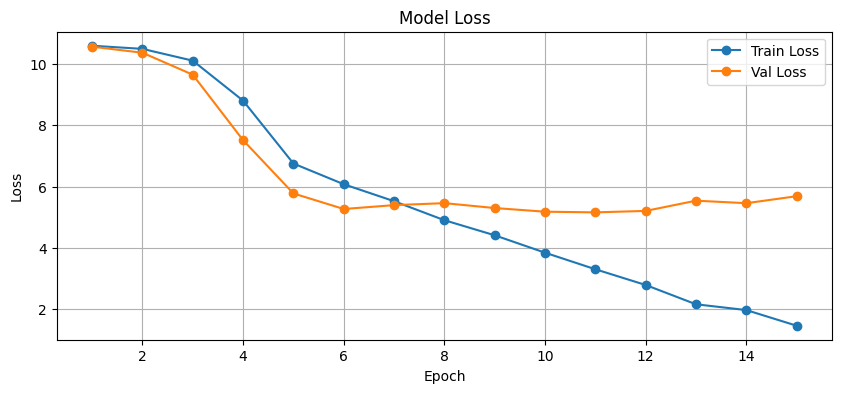

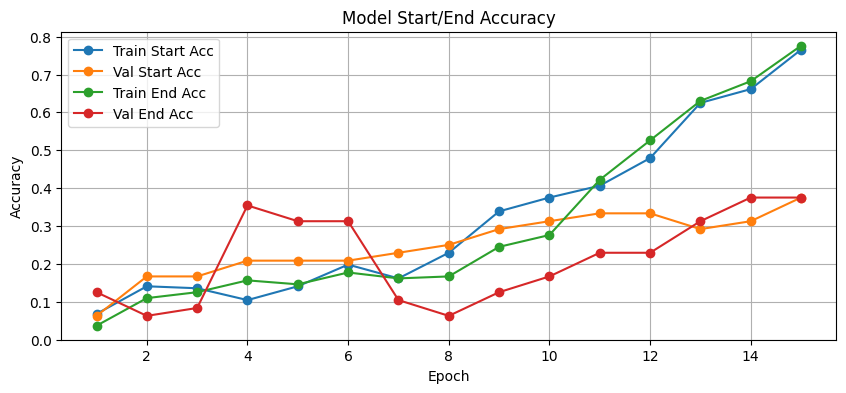

In [226]:
%matplotlib inline
import matplotlib.pyplot as plt

hist = history.history

train_loss = hist.get('loss', [])
val_loss = hist.get('val_loss', [])
train_acc_start = hist.get('start_accuracy', [])
train_acc_end = hist.get('end_accuracy', [])
val_acc_start = hist.get('val_start_accuracy', [])
val_acc_end = hist.get('val_end_accuracy', [])

epochs = range(1, len(train_loss) + 1)

# -------- Loss --------
plt.figure(figsize=(10, 4))
if train_loss:
    plt.plot(epochs, train_loss, marker='o', label='Train Loss')
if val_loss:
    plt.plot(epochs, val_loss, marker='o', label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# -------- Accuracy (Start/End) --------
plt.figure(figsize=(10, 4))
if train_acc_start:
    plt.plot(epochs, train_acc_start, marker='o', label='Train Start Acc')
if val_acc_start:
    plt.plot(epochs, val_acc_start, marker='o', label='Val Start Acc')
if train_acc_end:
    plt.plot(epochs, train_acc_end, marker='o', label='Train End Acc')
if val_acc_end:
    plt.plot(epochs, val_acc_end, marker='o', label='Val End Acc')
plt.title('Model Start/End Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [227]:
import random

def predict_answer(question, context):
    """
    Predict answer span using start/end position probabilities.
    Args:
        question: Question text
        context: Context/passage text
    Returns:
        Predicted answer span
    """
    if 'model' not in globals() or 'tokenizer' not in globals():
        print("يرجى تشغيل خلايا التدريب (model/tokenizer) أولاً.")
        return None

    if not question or not context:
        print("السؤال أو السياق فارغ.")
        return None

    question_clean = normalize_text(question)
    context_clean = normalize_text(context)

    question_encoded = tokenizer.texts_to_sequences([question_clean])
    context_encoded = tokenizer.texts_to_sequences([context_clean])

    question_padded = pad_sequences(question_encoded, maxlen=MAX_Q_LEN, padding='post')
    context_padded = pad_sequences(context_encoded, maxlen=MAX_C_LEN, padding='post')

    # Get probability distributions over positions
    start_probs, end_probs = qa_model.model.predict([question_padded, context_padded], verbose=0)
    
    # Extract argmax positions and confidence
    start_idx = int(np.argmax(start_probs[0]))
    end_idx = int(np.argmax(end_probs[0]))
    start_conf = float(np.max(start_probs[0]))
    end_conf = float(np.max(end_probs[0]))

    # Ensure valid span (end >= start)
    if end_idx < start_idx:
        end_idx = start_idx

    # Decode to text
    context_tokens = context_clean.split()
    # if not context_tokens:
    #     return ("" , 0.0) if return_confidence else ""

    # Clamp to valid range
    start_idx = max(0, min(start_idx, len(context_tokens) - 1))
    end_idx = max(start_idx, min(end_idx, len(context_tokens) - 1))

    predicted_span = " ".join(context_tokens[start_idx:end_idx + 1]).strip()
    
    return predicted_span


# Test with random example from dataset
idx = random.randint(0, len(data) - 1)
sample_item = data[idx]
sample_question = sample_item['question']
sample_context = sample_item['context']
ground_truth_answer = sample_item['answer']

predicted_answer = predict_answer(sample_question, sample_context)

print(f'📌 Example #{idx + 1} from dataset:')
print(f'\n❓ Question: {sample_question}')
print(f'\n📝 Context: {sample_context}')
print(f'\n✅ Ground Truth: {ground_truth_answer}')
print(f'\n🤖 Prediction: {predicted_answer}')
# print(f'\n📊 Confidence: {confidence:.2%}')

📌 Example #228 from dataset:

❓ Question: لماذا لا يوجد تماثل بين قبري شاه جهان وممتاز محل؟

📝 Context: مكان ضريح السلطان ما كانش متخططله، هو اتحط هنا وخلاص.

✅ Ground Truth: لانه لم يكن مخططا لدفنه هناك

🤖 Prediction: ما كانش متخططله، هو اتحط


# Transformer

## Source Encoding For QA Pair
This cell builds the encoder source sequence as [Q] question [SEP] [C] context so both question and context are explicitly represented before entering the Transformer.

In [228]:
from torch.utils.data import DataLoader, random_split

BASE_VOCAB_SIZE = vocab_size
PAD_IDX = 0
SOS_IDX = BASE_VOCAB_SIZE
EOS_IDX = BASE_VOCAB_SIZE + 1
SEP_IDX = BASE_VOCAB_SIZE + 2
Q_IDX = BASE_VOCAB_SIZE + 3
C_IDX = BASE_VOCAB_SIZE + 4
TOTAL_VOCAB_SIZE = BASE_VOCAB_SIZE + 5

MAX_SRC_LEN = MAX_Q_LEN + MAX_C_LEN + 3  # [Q] question [SEP] [C] context
MAX_TGT_LEN = MAX_A_LEN + 2

dataset = QADataset(q_tensor.long(), c_tensor.long(), a_tensor.long())
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_ds, val_ds = random_split(
    dataset, [train_size, val_size], generator=torch.Generator().manual_seed(42)
)

def qa_collate(batch):
    q_batch, c_batch, a_batch = zip(*batch)
    q_batch = torch.stack(q_batch)
    c_batch = torch.stack(c_batch)
    a_batch = torch.stack(a_batch)

    q_tag = torch.full((q_batch.size(0), 1), Q_IDX, dtype=torch.long)
    sep_column = torch.full((q_batch.size(0), 1), SEP_IDX, dtype=torch.long)
    c_tag = torch.full((q_batch.size(0), 1), C_IDX, dtype=torch.long)
    src = torch.cat([q_tag, q_batch, sep_column, c_tag, c_batch], dim=1)[:, :MAX_SRC_LEN]

    sos_column = torch.full((a_batch.size(0), 1), SOS_IDX, dtype=torch.long)
    eos_column = torch.full((a_batch.size(0), 1), EOS_IDX, dtype=torch.long)
    a_trim = a_batch[:, :MAX_A_LEN]
    tgt_full = torch.cat([sos_column, a_trim, eos_column], dim=1)[:, :MAX_TGT_LEN]

    tgt_inp = tgt_full[:, :-1]
    tgt_out = tgt_full[:, 1:]
    return src, tgt_inp, tgt_out

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, collate_fn=qa_collate)
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False, collate_fn=qa_collate)

print(f"train samples: {len(train_ds)}")
print(f"val samples: {len(val_ds)}")
print(f"total vocabulary (with special tokens): {TOTAL_VOCAB_SIZE}")

train samples: 192
val samples: 48
total vocabulary (with special tokens): 2387


In [229]:

import math
import torch
import torch.nn as nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cpu


In [230]:
idx_to_word = tokenizer.index_word

def decode_ids(ids, drop_special=True):
    words = []
    for idx in ids:
        idx = int(idx)
        if idx == PAD_IDX:
            continue
        if idx == SOS_IDX:
            if not drop_special:
                words.append("<sos>")
            continue
        if idx == EOS_IDX:
            if not drop_special:
                words.append("<eos>")
            break
        if idx == SEP_IDX:
            if not drop_special:
                words.append("<sep>")
            continue
        if idx == Q_IDX:
            if not drop_special:
                words.append("<q>")
            continue
        if idx == C_IDX:
            if not drop_special:
                words.append("<c>")
            continue
        words.append(idx_to_word.get(idx, "<unk>"))
    return " ".join(words)

print("example question:", data[0]["question"] if data else "N/A")
print("example answer:", data[0]["answer"] if data else "N/A")

example question: ما الحدث الذي جعل اورسون ويلز مشهورا قبل دخوله السينما؟
example answer: تمثيليه اذاعيه عن غزو فضائي


In [231]:
# Confirm one batch shape after the 80/20 split and collate pipeline.
src_b, tgt_inp_b, tgt_out_b = next(iter(train_loader))
print("src batch:", tuple(src_b.shape))
print("tgt input batch:", tuple(tgt_inp_b.shape))
print("tgt output batch:", tuple(tgt_out_b.shape))

src batch: (32, 303)
tgt input batch: (32, 71)
tgt output batch: (32, 71)


## Positional Encoding
This cell adds positional signals to token embeddings so the model can distinguish token order in question, context, and generated answer sequences.

In [232]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=512, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(
            torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x):
        x = x + self.pe[:, : x.size(1)]
        return self.dropout(x)

## Scaled Dot-Product Attention
This is the core attention operation that computes attention weights between queries and keys, then aggregates values (with causal and padding masks).

In [233]:
class ScaledDotProductAttention(nn.Module):
    def forward(self, q, k, v, attn_mask=None, key_padding_mask=None):
        d_k = q.size(-1)
        scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(d_k)

        if attn_mask is not None:
            scores = scores.masked_fill(attn_mask == 0, -1e9)

        if key_padding_mask is not None:
            # key_padding_mask: [B, T_k], True indicates PAD positions to ignore.
            scores = scores.masked_fill(
                key_padding_mask.unsqueeze(1).unsqueeze(2), -1e9
            )

        attn = torch.softmax(scores, dim=-1)
        return torch.matmul(attn, v), attn

## Multi-Head Attention
This cell splits attention into multiple heads so the model can learn different alignment patterns in parallel, then concatenates them back.

In [234]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, n_heads):
        super().__init__()
        assert d_model % n_heads == 0
        self.n_heads = n_heads
        self.d_k = d_model // n_heads
        self.w_q = nn.Linear(d_model, d_model)
        self.w_k = nn.Linear(d_model, d_model)
        self.w_v = nn.Linear(d_model, d_model)
        self.fc = nn.Linear(d_model, d_model)
        self.attn_mod = ScaledDotProductAttention()
        self.last_attention = None

    def forward(self, query, key, value, attn_mask=None, key_padding_mask=None):
        B, T_q, D = query.shape
        T_k = key.size(1)
        H, d_k = self.n_heads, self.d_k

        Q = self.w_q(query).view(B, T_q, H, d_k).transpose(1, 2)
        K = self.w_k(key).view(B, T_k, H, d_k).transpose(1, 2)
        V = self.w_v(value).view(B, T_k, H, d_k).transpose(1, 2)

        out, attn = self.attn_mod(
            Q, K, V, attn_mask=attn_mask, key_padding_mask=key_padding_mask
        )
        self.last_attention = attn
        out = out.transpose(1, 2).contiguous().view(B, T_q, D)
        return self.fc(out)


def causal_mask(size, device):
    return torch.tril(torch.ones(size, size, device=device)).bool()


def pad_key_mask(ids, pad_idx):
    return ids == pad_idx

## Encoder Layer (Self-Attention + Residual)
This encoder block applies self-attention over the source tokens, then a feed-forward network, both wrapped with residual connections and layer normalization.

In [235]:
class EncoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, ff_dim=256, dropout=0.1, use_residual=True):
        super().__init__()
        self.use_residual = use_residual
        self.self_attn = MultiHeadAttention(d_model, n_heads)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)
        self.ff = nn.Sequential(
            nn.Linear(d_model, ff_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(ff_dim, d_model),
        )

    def forward(self, x, src_key_padding_mask):
        attn_out = self.self_attn(
            x, x, x, attn_mask=None, key_padding_mask=src_key_padding_mask
        )
        if self.use_residual:
            x = self.norm1(x + self.dropout(attn_out))
        else:
            x = self.norm1(self.dropout(attn_out))

        ff_out = self.ff(x)
        if self.use_residual:
            x = self.norm2(x + self.dropout(ff_out))
        else:
            x = self.norm2(self.dropout(ff_out))
        return x

## Decoder Layer (Self-Attention + Cross-Attention + Residual)
This decoder block uses masked self-attention over generated tokens, then cross-attention to encoder outputs (question+context), followed by feed-forward, each with residual paths.

In [236]:
class DecoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, ff_dim=256, dropout=0.1):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, n_heads)
        self.cross_attn = MultiHeadAttention(d_model, n_heads)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.norm3 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)
        self.ff = nn.Sequential(
            nn.Linear(d_model, ff_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(ff_dim, d_model),
        )

    def forward(self, x, enc_out, tgt_mask, src_key_padding_mask, tgt_key_padding_mask=None):
        self_attn_out = self.self_attn(
            x,
            x,
            x,
            attn_mask=tgt_mask,
            key_padding_mask=tgt_key_padding_mask,
        )
        x = self.norm1(x + self.dropout(self_attn_out))

        cross_attn_out = self.cross_attn(
            x,
            enc_out,
            enc_out,
            attn_mask=None,
            key_padding_mask=src_key_padding_mask,
        )
        x = self.norm2(x + self.dropout(cross_attn_out))

        ff_out = self.ff(x)
        x = self.norm3(x + self.dropout(ff_out))
        return x

## Full Transformer Initialization
This cell initializes the main Transformer attributes: embeddings, positional encoders, encoder, decoder, and output projection layer for vocabulary logits.

In [237]:
class Transformer(nn.Module):
    def __init__(
        self,
        src_vocab,
        tgt_vocab,
        d_model=128,
        n_heads=4,
        ff_dim=256,
        dropout=0.2,
        use_residual_encoder=True,
        use_positional_encoding=True,
    ):
        super().__init__()
        self.d_model = d_model
        self.use_positional_encoding = use_positional_encoding
        self.src_emb = nn.Embedding(src_vocab, d_model, padding_idx=PAD_IDX)
        self.tgt_emb = nn.Embedding(tgt_vocab, d_model, padding_idx=PAD_IDX)
        self.pos_src = PositionalEncoding(d_model, max_len=MAX_SRC_LEN, dropout=dropout)
        self.pos_tgt = PositionalEncoding(d_model, max_len=MAX_TGT_LEN, dropout=dropout)
        self.encoder = EncoderLayer(
            d_model, n_heads, ff_dim=ff_dim, dropout=dropout, use_residual=use_residual_encoder
        )
        self.decoder = DecoderLayer(d_model, n_heads, ff_dim=ff_dim, dropout=dropout)
        self.fc = nn.Linear(d_model, tgt_vocab)

    def embed_src(self, src):
        x = self.src_emb(src) * math.sqrt(self.d_model)
        if self.use_positional_encoding:
            x = self.pos_src(x)
        return x

    def embed_tgt(self, tgt):
        x = self.tgt_emb(tgt) * math.sqrt(self.d_model)
        if self.use_positional_encoding:
            x = self.pos_tgt(x)
        return x

    def forward(self, src, tgt):
        src_key_padding_mask = pad_key_mask(src, PAD_IDX)
        tgt_key_padding_mask = pad_key_mask(tgt, PAD_IDX)
        tgt_mask = causal_mask(tgt.size(1), tgt.device)

        enc = self.encoder(
            self.embed_src(src), src_key_padding_mask=src_key_padding_mask
        )
        dec = self.decoder(
            self.embed_tgt(tgt),
            enc,
            tgt_mask=tgt_mask,
            src_key_padding_mask=src_key_padding_mask,
            tgt_key_padding_mask=tgt_key_padding_mask,
        )
        return self.fc(dec)

In [238]:
def trace_shapes(model, src_b, tgt_b):
    model.eval()
    B, T_src = src_b.shape
    _, T_tgt = tgt_b.shape
    D = model.d_model
    H = model.encoder.self_attn.n_heads
    dk = D // H
    print(f"B={B}, T_src={T_src}, T_tgt={T_tgt}, D={D}, H={H}, d_k={dk}")
    with torch.no_grad():
        src_pad = pad_key_mask(src_b, PAD_IDX)
        emb_s = model.embed_src(src_b)
        print(f"embed_src out:        {tuple(emb_s.shape)}")
        enc = model.encoder(emb_s, src_key_padding_mask=src_pad)
        print(f"encoder out:          {tuple(enc.shape)}")
        tgt_mask = causal_mask(T_tgt, tgt_b.device)
        tgt_pad = pad_key_mask(tgt_b, PAD_IDX)
        emb_t = model.embed_tgt(tgt_b)
        print(f"embed_tgt out:        {tuple(emb_t.shape)}")
        dec = model.decoder(emb_t, enc, tgt_mask, src_pad, tgt_pad)
        print(f"decoder out:          {tuple(dec.shape)}")
        logits = model.fc(dec)
        print(f"lm logits:            {tuple(logits.shape)}")
        print(
            "inside MHA, Q/K/V are reshaped to (B, H, T, d_k) and attention scores are (B, H, T_q, T_k)"
        )

src_batch, tgt_input_batch, _ = next(iter(train_loader))
src_1 = src_batch[:1].to(device)
tgt_1 = tgt_input_batch[:1].to(device)
trace_shapes(Transformer(TOTAL_VOCAB_SIZE, TOTAL_VOCAB_SIZE).to(device), src_1, tgt_1)

B=1, T_src=303, T_tgt=71, D=128, H=4, d_k=32
embed_src out:        (1, 303, 128)
encoder out:          (1, 303, 128)
embed_tgt out:        (1, 71, 128)
decoder out:          (1, 71, 128)
lm logits:            (1, 71, 2387)
inside MHA, Q/K/V are reshaped to (B, H, T, d_k) and attention scores are (B, H, T_q, T_k)


In [239]:
import copy

def evaluate_loss(model, loader, loss_fn):
    model.eval()
    total_loss = 0.0
    total_batches = 0
    with torch.no_grad():
        for src, tgt_inp, tgt_out in loader:
            src = src.to(device)
            tgt_inp = tgt_inp.to(device)
            tgt_out = tgt_out.to(device)
            logits = model(src, tgt_inp)
            loss = loss_fn(logits.reshape(-1, logits.size(-1)), tgt_out.reshape(-1))
            total_loss += loss.item()
            total_batches += 1
    return total_loss / max(total_batches, 1)


def train_model(
    model,
    train_loader,
    val_loader,
    epochs=20,
    lr=7e-4,
    clip_grad=1.0,
    weight_decay=1e-4,
    patience=6,
    min_delta=1e-3,
    label_smoothing=0.1,
    return_batch_losses=False,
    ):
    model = model.to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=2
    )
    loss_fn = nn.CrossEntropyLoss(ignore_index=PAD_IDX, label_smoothing=label_smoothing)

    history = []
    batch_losses = [] if return_batch_losses else None

    best_val_loss = float("inf")
    best_state = None
    no_improve_epochs = 0

    for epoch in range(epochs):
        model.train()
        running = 0.0
        n_batches = 0

        for src, tgt_inp, tgt_out in train_loader:
            src = src.to(device)
            tgt_inp = tgt_inp.to(device)
            tgt_out = tgt_out.to(device)

            logits = model(src, tgt_inp)
            loss = loss_fn(logits.reshape(-1, logits.size(-1)), tgt_out.reshape(-1))

            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), clip_grad)
            optimizer.step()

            running += loss.item()
            n_batches += 1
            if return_batch_losses:
                batch_losses.append(loss.item())

        train_loss = running / max(n_batches, 1)
        val_loss = evaluate_loss(model, val_loader, loss_fn)
        scheduler.step(val_loss)
        current_lr = optimizer.param_groups[0]["lr"]

        history.append({"train_loss": train_loss, "val_loss": val_loss, "lr": current_lr})
        print(
            f"epoch {epoch + 1}/{epochs} - lr: {current_lr:.6f} - train_loss: {train_loss:.4f} - val_loss: {val_loss:.4f}"
        )

        if val_loss < best_val_loss - min_delta:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            no_improve_epochs = 0
        else:
            no_improve_epochs += 1
            if no_improve_epochs >= patience:
                print(
                    f"Early stopping at epoch {epoch + 1}; best val_loss: {best_val_loss:.4f}"
                )
                break

    if best_state is not None:
        model.load_state_dict(best_state)
        print(f"Restored best model with val_loss: {best_val_loss:.4f}")

    if return_batch_losses:
        return history, batch_losses
    return history

#here
trans_model = Transformer(TOTAL_VOCAB_SIZE, TOTAL_VOCAB_SIZE, dropout=0.2).to(device)
history = train_model(
    trans_model, train_loader, val_loader, epochs=40, lr=7e-4, patience=6, label_smoothing=0.1
)
epochs_ran = len(history)
best_val = min(h['val_loss'] for h in history) if history else float('nan')
print(f"Training summary: epochs_ran={epochs_ran}, best_val_loss={best_val:.4f}")

epoch 1/40 - lr: 0.000700 - train_loss: 7.6784 - val_loss: 7.0658
epoch 2/40 - lr: 0.000700 - train_loss: 6.8454 - val_loss: 6.8334
epoch 3/40 - lr: 0.000700 - train_loss: 6.4392 - val_loss: 6.7406
epoch 4/40 - lr: 0.000700 - train_loss: 6.1267 - val_loss: 6.6085
epoch 5/40 - lr: 0.000700 - train_loss: 5.8534 - val_loss: 6.5466
epoch 6/40 - lr: 0.000700 - train_loss: 5.6175 - val_loss: 6.5220
epoch 7/40 - lr: 0.000700 - train_loss: 5.4254 - val_loss: 6.5038
epoch 8/40 - lr: 0.000700 - train_loss: 5.2691 - val_loss: 6.4850
epoch 9/40 - lr: 0.000700 - train_loss: 5.1088 - val_loss: 6.4822
epoch 10/40 - lr: 0.000700 - train_loss: 4.9668 - val_loss: 6.4433
epoch 11/40 - lr: 0.000700 - train_loss: 4.8291 - val_loss: 6.3926
epoch 12/40 - lr: 0.000700 - train_loss: 4.6854 - val_loss: 6.3701
epoch 13/40 - lr: 0.000700 - train_loss: 4.5249 - val_loss: 6.3258
epoch 14/40 - lr: 0.000700 - train_loss: 4.3993 - val_loss: 6.2960
epoch 15/40 - lr: 0.000700 - train_loss: 4.2751 - val_loss: 6.2489
epoc

In [240]:
@torch.no_grad()
def greedy_decode(model, src_ids, max_len=8):
    model.eval()
    src_ids = src_ids.unsqueeze(0).to(device)
    ys = torch.tensor([[SOS_IDX]], device=device, dtype=torch.long)

    for _ in range(max_len - 1):
        logits = model(src_ids, ys)
        next_id = logits[:, -1, :].argmax(dim=-1, keepdim=True)
        ys = torch.cat([ys, next_id], dim=1)
        if next_id.item() == EOS_IDX:
            break
    return ys[0].cpu().tolist()


def decode_answer(ids):
    words = []
    for idx in ids:
        idx = int(idx)
        if idx in (PAD_IDX, SOS_IDX, SEP_IDX, Q_IDX, C_IDX):
            continue
        if idx == EOS_IDX:
            break
        words.append(idx_to_word.get(idx, "<unk>"))
    return " ".join(words).strip()


def encode_text_fixed(text, max_len):
    seq = tokenizer.texts_to_sequences([text])[0]
    seq = seq[:max_len] + [PAD_IDX] * max(0, max_len - len(seq))
    return seq[:max_len]


def build_src_from_text(question, context):
    q_ids = torch.tensor(encode_text_fixed(question, MAX_Q_LEN), dtype=torch.long)
    c_ids = torch.tensor(encode_text_fixed(context, MAX_C_LEN), dtype=torch.long)
    q_tag = torch.tensor([Q_IDX], dtype=torch.long)
    sep = torch.tensor([SEP_IDX], dtype=torch.long)
    c_tag = torch.tensor([C_IDX], dtype=torch.long)
    src = torch.cat([q_tag, q_ids, sep, c_tag, c_ids], dim=0)
    return src[:MAX_SRC_LEN]


def answer_question(model, question, context):
    src = build_src_from_text(question, context)
    out_ids = greedy_decode(model, src)
    return decode_answer(out_ids)


# Demo on one example from the original dataframe/list after training
demo_q = data[0]["question"] if data else ""
demo_c = data[0]["context"] if data else ""
demo_ref = data[0]["answer"] if data else ""
print("question:", demo_q)
print("context:", demo_c)
print("reference:", demo_ref)
#here
print("prediction:", answer_question(trans_model, demo_q, demo_c))

question: ما الحدث الذي جعل اورسون ويلز مشهورا قبل دخوله السينما؟
context: في ليله 30 اكتوبر 1938، انقطع بث اذاعي ليعلن عن غزو فضائي في نيوجيرسي. تسبب ذلك في ذعر واسع لان الناس صدقوا الخبر. لاحقا تبين ان الحدث كان تمثيليه اذاعيه من اخراج اورسون ويلز. هذه التجربه اثبتت قدرته علي التاثير في الجمهور.
reference: تمثيليه اذاعيه عن غزو فضائي
prediction: تقديم بث اذاعي تسبب في ذعر جماهيري


In [241]:
@torch.no_grad()
def teacher_forcing_token_accuracy(model, loader):
    model.eval()
    correct, total = 0, 0
    for src, tgt_inp, tgt_out in loader:
        src = src.to(device)
        tgt_inp = tgt_inp.to(device)
        tgt_out = tgt_out.to(device)
        logits = model(src, tgt_inp)
        pred = logits.argmax(dim=-1)
        mask = tgt_out != PAD_IDX
        correct += (pred[mask] == tgt_out[mask]).sum().item()
        total += mask.sum().item()
    return correct / max(total, 1)


def token_f1(pred_text, ref_text):
    pred_tokens = pred_text.split()
    ref_tokens = ref_text.split()
    if not pred_tokens and not ref_tokens:
        return 1.0
    if not pred_tokens or not ref_tokens:
        return 0.0

    pred_set = {}
    for t in pred_tokens:
        pred_set[t] = pred_set.get(t, 0) + 1
    ref_set = {}
    for t in ref_tokens:
        ref_set[t] = ref_set.get(t, 0) + 1

    overlap = 0
    for t, c in pred_set.items():
        overlap += min(c, ref_set.get(t, 0))

    precision = overlap / max(len(pred_tokens), 1)
    recall = overlap / max(len(ref_tokens), 1)
    if precision + recall == 0:
        return 0.0
    return 2 * precision * recall / (precision + recall)


@torch.no_grad()
def evaluate_generation(model, dataset_split, max_samples=120):
    model.eval()
    n = min(len(dataset_split), max_samples)
    exact_match = 0
    f1_total = 0.0

    for i in range(n):
        q_ids, c_ids, a_ids = dataset_split[i]
        q_tag = torch.tensor([Q_IDX])
        sep = torch.tensor([SEP_IDX])
        c_tag = torch.tensor([C_IDX])
        src = torch.cat([q_tag, q_ids.long(), sep, c_tag, c_ids.long()], dim=0)[:MAX_SRC_LEN]
        pred_ids = greedy_decode(model, src)
        pred = decode_answer(pred_ids)
        ref = decode_answer([SOS_IDX] + a_ids.tolist() + [EOS_IDX])

        if pred == ref:
            exact_match += 1
        f1_total += token_f1(pred, ref)

    if n == 0:
        return 0.0, 0.0
    return exact_match / n, f1_total / n

#here
train_acc = teacher_forcing_token_accuracy(trans_model, train_loader)
#here
val_acc = teacher_forcing_token_accuracy(trans_model, val_loader)
#here
em, f1 = evaluate_generation(trans_model, val_ds, max_samples=100)
print(f"Train token accuracy: {train_acc:.4f}")
print(f"Validation token accuracy: {val_acc:.4f}")
print(f"Validation Exact Match: {em:.4f}")
print(f"Validation token-F1: {f1:.4f}")

Train token accuracy: 0.9434
Validation token accuracy: 0.4082
Validation Exact Match: 0.0208
Validation token-F1: 0.1122


In [242]:
# model = trans_model

In [243]:
@torch.no_grad()
def show_hard_validation_examples(model, subset, n_examples=10):
    model.eval()
    rows = []
    total = len(subset)

    for i in range(total):
        q_ids, c_ids, a_ids = subset[i]
        q_tag = torch.tensor([Q_IDX])
        sep = torch.tensor([SEP_IDX])
        c_tag = torch.tensor([C_IDX])
        src = torch.cat([q_tag, q_ids.long(), sep, c_tag, c_ids.long()], dim=0)[:MAX_SRC_LEN]
        pred_ids = greedy_decode(model, src)
        pred_text = decode_answer(pred_ids)
        ref_text = decode_answer([SOS_IDX] + a_ids.tolist() + [EOS_IDX])
        f1_score = token_f1(pred_text, ref_text)

        if hasattr(subset, "indices"):
            original_idx = subset.indices[i]
            q_text = data[original_idx]["question"]
            c_text = data[original_idx]["context"]
        else:
            q_text = "[question unavailable]"
            c_text = "[context unavailable]"

        rows.append(
            {
                "i": i,
                "f1": f1_score,
                "question": q_text,
                "context": c_text,
                "reference": ref_text,
                "prediction": pred_text,
            }
        )

    rows.sort(key=lambda x: x["f1"])
    worst = rows[:n_examples]
    best = rows[-n_examples:]

    print(f"Worst {len(worst)} validation examples by token-F1:")
    for r in worst:
        print("\n" + "=" * 90)
        print(f"sample={r['i']} | f1={r['f1']:.4f}")
        print(f"Q: {r['question']}")
        print(f"Ref: {r['reference']}")
        print(f"Pred: {r['prediction']}")
        print(f"Context preview: {r['context'][:220]}...")

    for r in best:
        print("\n" + "=" * 90)
        print(f"sample={r['i']} | f1={r['f1']:.4f}")
        print(f"Q: {r['question']}")
        print(f"Ref: {r['reference']}")
        print(f"Pred: {r['prediction']}")
        print(f"Context preview: {r['context'][:220]}...")

show_hard_validation_examples(trans_model, val_ds, n_examples=10)

Worst 10 validation examples by token-F1:

sample=0 | f1=0.0000
Q: ما استراتيجيه بطرس بعد الهزيمه؟
Ref: استنزاف العدو تدريجيا وتجنب المعارك الحاسمه
Pred: بسبب حركتها المجنونه والمستمره تبني النمط الاوروبي
Context preview: مش عايزين نخسر اوي نستنزف السويديين واحده واحده....

sample=3 | f1=0.0000
Q: ما الحدث الذي انهي حكم المغول في الهند؟
Ref: ثوره 1857 ضد الاستعمار البريطاني
Pred: اول ما لانهايه اللحظه بالظبط مثل فيروسات
Context preview: سنه 1857 طلعت اول ثوره للهند ضد الاستعمار الانجليزي....

sample=4 | f1=0.0000
Q: ما العامل الذي غير طبيعه القتال الجوي؟
Ref: الرادار
Pred: بتفضل تتحرك من غير ما تقف غير
Context preview: الرادار، يا عزيزي، اعاد تعريف المعركه الجويه. دلوقتي مش اللي اسرع ولا اللي بيعمل مناورات احسن، اللي يكسب هو اللي يقدر يتسلل....

sample=5 | f1=0.0000
Q: كيف اثر السهل الاوروبي علي قدره الجيوش في الوصول الي روسيا؟
Ref: سمح للجيوش بالتحرك بسهوله دون عوائق
Pred: باستخدام خلايا جلديه تغير اللون والملمس باستخدام
Context preview: مساحه سهل اي جيش يقطعها ويخش روسيا....

sample=

In [245]:
print(f"epochs_ran: {epochs_ran}")
print(f"best_val_loss: {best_val:.4f}")

epochs_ran: 40
best_val_loss: 5.6774


# Transformer v2 — Dual-Encoder Architecture

## Motivation: Why Separate Encoders?

The original Transformer concatenates question and context into one sequence:
```
[Q] q₁…qₙ [SEP] [C] c₁…cₘ  →  single encoder  →  decoder
```

The problem: self-attention over this combined 303-token sequence means every question
token competes with every context token for attention from the very first layer.
The model has no dedicated phase to first "understand" the question before reading the context.

This new architecture uses **two separate encoders**:

```
Question  →  Encoder_Q  →  Q_repr   (shape: B, MAX_Q_LEN, D)
Context   →  Encoder_C  →  C_repr   (shape: B, MAX_C_LEN, D)
```

Then a **fusion layer** uses cross-attention to let the context representation
attend to the question — producing a question-aware context encoding.
This fused representation is then passed to the same decoder.

This mirrors how reading comprehension actually works:
first understand the question, then re-read the context with that question in mind.



## Architecture Overview

```
Question tokens                    Context tokens
      │                                  │
  Embedding + PE                   Embedding + PE
      │                                  │
  EncoderLayer_Q                   EncoderLayer_C
  (self-attention                  (self-attention
   over question)                   over context)
      │                                  │
      └──────────── Fusion ──────────────┘
                      │
              CrossAttentionFusion
              (context attends to question)
                      │
              FusedContextRepr
                      │
                  DecoderLayer
              (self-attn + cross-attn
               over fused context)
                      │
               Linear → vocab logits
                      │
                Answer tokens (greedy decode)
```

**Parameter comparison vs original Transformer:**

| Component | Original | Dual-Encoder |
|---|---|---|
| Encoder | 1 × EncoderLayer over 303 tokens | 2 × EncoderLayer (Q + C separately) |
| Fusion | None (SEP token only) | Explicit CrossAttention layer |
| Decoder | 1 × DecoderLayer | 1 × DecoderLayer (same) |
| Output | Linear(d_model → vocab) | Linear(d_model → vocab) (same) |

In [246]:
# ── Transformer v2: Dual-Encoder + Cross-Attention Fusion + Decoder ──────────
import math, torch, torch.nn as nn, copy

class DualEncoderTransformerQA(nn.Module):
    def __init__(
        self,
        vocab_size,
        d_model=128,
        n_heads=4,
        ff_dim=256,
        dropout=0.2,
    ):
        super().__init__()
        self.d_model = d_model

        # ── Shared embedding (question and context share the same vocab)
        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=PAD_IDX)

        # ── Separate positional encodings (different max lengths)
        self.pos_q = PositionalEncoding(d_model, max_len=MAX_Q_LEN + 10, dropout=dropout)
        self.pos_c = PositionalEncoding(d_model, max_len=MAX_C_LEN + 10, dropout=dropout)
        self.pos_t = PositionalEncoding(d_model, max_len=MAX_TGT_LEN + 10, dropout=dropout)

        # ── Dedicated encoder for question
        self.q_encoder = EncoderLayer(d_model, n_heads, ff_dim=ff_dim, dropout=dropout)

        # ── Dedicated encoder for context
        self.c_encoder = EncoderLayer(d_model, n_heads, ff_dim=ff_dim, dropout=dropout)

        # ── Fusion: context cross-attends to question
        # Query = context repr, Key/Value = question repr
        self.fusion_attn  = MultiHeadAttention(d_model, n_heads)
        self.fusion_norm  = nn.LayerNorm(d_model)
        self.fusion_ff    = nn.Sequential(
            nn.Linear(d_model, ff_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(ff_dim, d_model),
        )
        self.fusion_norm2 = nn.LayerNorm(d_model)
        self.fusion_drop  = nn.Dropout(dropout)

        # ── Decoder (same structure as original)
        self.decoder = DecoderLayer(d_model, n_heads, ff_dim=ff_dim, dropout=dropout)

        # ── Output projection
        self.fc = nn.Linear(d_model, vocab_size)

    # ── Embedding helpers
    def _embed_q(self, q):
        return self.pos_q(self.embedding(q) * math.sqrt(self.d_model))

    def _embed_c(self, c):
        return self.pos_c(self.embedding(c) * math.sqrt(self.d_model))

    def _embed_t(self, t):
        return self.pos_t(self.embedding(t) * math.sqrt(self.d_model))

    def forward(self, q, c, tgt):
        """
        q   : (B, MAX_Q_LEN)   — padded question token ids
        c   : (B, MAX_C_LEN)   — padded context token ids
        tgt : (B, T_tgt-1)     — teacher-forced answer input
        """
        # ── Padding masks
        q_pad   = (q   == PAD_IDX)   # (B, MAX_Q_LEN)
        c_pad   = (c   == PAD_IDX)   # (B, MAX_C_LEN)
        tgt_pad = (tgt == PAD_IDX)   # (B, T_tgt)

        # ── Step 1: Encode question independently
        q_repr = self.q_encoder(
            self._embed_q(q),
            src_key_padding_mask=q_pad
        )                            # (B, MAX_Q_LEN, D)

        # ── Step 2: Encode context independently
        c_repr = self.c_encoder(
            self._embed_c(c),
            src_key_padding_mask=c_pad
        )                            # (B, MAX_C_LEN, D)

        # ── Step 3: Fusion — context cross-attends to question
        # "Given what the question asks, which parts of the context matter?"
        fused = self.fusion_attn(
            query=c_repr,            # context asks the question
            key=q_repr,
            value=q_repr,
            attn_mask=None,
            key_padding_mask=q_pad  # ignore padding in question
        )
        # Residual + norm (context repr enriched with question awareness)
        fused = self.fusion_norm(c_repr + self.fusion_drop(fused))  # (B, MAX_C_LEN, D)
        # Feed-forward
        fused = self.fusion_norm2(
            fused + self.fusion_drop(self.fusion_ff(fused))
        )                            # (B, MAX_C_LEN, D)

        # ── Step 4: Decode answer attending to fused context
        tgt_mask = causal_mask(tgt.size(1), tgt.device)
        dec = self.decoder(
            x=self._embed_t(tgt),
            enc_out=fused,           # decoder cross-attends to fused context
            tgt_mask=tgt_mask,
            src_key_padding_mask=c_pad,   # fused has same shape as c
            tgt_key_padding_mask=tgt_pad,
        )                            # (B, T_tgt, D)

        return self.fc(dec)          # (B, T_tgt, vocab_size)

## Dataset & DataLoader

The dual encoder takes **separate** `q` and `c` tensors instead of one concatenated `src`.
We reuse `q_tensor`, `c_tensor`, `a_tensor` already built above, and the same 80/20 split
seed so results are directly comparable to the original Transformer.

In [247]:
# ── Dataset & DataLoaders for Dual-Encoder ──────────────────────────────────
from torch.utils.data import DataLoader, random_split

class DualQADataset(torch.utils.data.Dataset):
    def __init__(self, q, c, a):
        self.q = q
        self.c = c
        self.a = a

    def __len__(self):
        return len(self.q)

    def __getitem__(self, idx):
        return self.q[idx], self.c[idx], self.a[idx]


def dual_collate(batch):
    q_b, c_b, a_b = zip(*batch)
    q_b = torch.stack(q_b).long()
    c_b = torch.stack(c_b).long()
    a_b = torch.stack(a_b).long()

    # Build teacher-forced target: [SOS] answer, answer [EOS]
    sos_col = torch.full((a_b.size(0), 1), SOS_IDX, dtype=torch.long)
    eos_col = torch.full((a_b.size(0), 1), EOS_IDX, dtype=torch.long)
    a_trim  = a_b[:, :MAX_A_LEN]
    tgt_full = torch.cat([sos_col, a_trim, eos_col], dim=1)[:, :MAX_TGT_LEN]

    tgt_inp = tgt_full[:, :-1]   # decoder input
    tgt_out = tgt_full[:, 1:]    # prediction target

    return q_b, c_b, tgt_inp, tgt_out


dual_dataset = DualQADataset(q_tensor, c_tensor, a_tensor)

dual_train_size = int(0.8 * len(dual_dataset))
dual_val_size   = len(dual_dataset) - dual_train_size

dual_train_ds, dual_val_ds = random_split(
    dual_dataset, [dual_train_size, dual_val_size],
    generator=torch.Generator().manual_seed(42)   # same split as original
)

dual_train_loader = DataLoader(
    dual_train_ds, batch_size=32, shuffle=True,  collate_fn=dual_collate
)
dual_val_loader = DataLoader(
    dual_val_ds,   batch_size=32, shuffle=False, collate_fn=dual_collate
)

# Sanity check
q_b, c_b, ti_b, to_b = next(iter(dual_train_loader))
print(f"question batch : {tuple(q_b.shape)}")
print(f"context  batch : {tuple(c_b.shape)}")
print(f"tgt input      : {tuple(ti_b.shape)}")
print(f"tgt output     : {tuple(to_b.shape)}")
print(f"train samples  : {dual_train_size}  |  val samples: {dual_val_size}")

question batch : (32, 100)
context  batch : (32, 200)
tgt input      : (32, 71)
tgt output     : (32, 71)
train samples  : 192  |  val samples: 48


In [248]:
# ── Train Dual-Encoder Transformer ──────────────────────────────────────────

def dual_evaluate_loss(model, loader, loss_fn):
    model.eval()
    total, n = 0.0, 0
    with torch.no_grad():
        for q, c, tgt_inp, tgt_out in loader:
            q, c = q.to(device), c.to(device)
            tgt_inp, tgt_out = tgt_inp.to(device), tgt_out.to(device)
            logits = model(q, c, tgt_inp)
            total += loss_fn(
                logits.reshape(-1, logits.size(-1)),
                tgt_out.reshape(-1)
            ).item()
            n += 1
    return total / max(n, 1)


def train_dual_model(
    model, train_loader, val_loader,
    epochs=40, lr=7e-4, clip=1.0,
    weight_decay=1e-4, patience=6,
    label_smoothing=0.1,
):
    model = model.to(device)
    optimizer = torch.optim.AdamW(
        model.parameters(), lr=lr, weight_decay=weight_decay
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=2
    )
    loss_fn = nn.CrossEntropyLoss(
        ignore_index=PAD_IDX, label_smoothing=label_smoothing
    )

    best_val, best_state, no_improve = float('inf'), None, 0
    history = []

    for epoch in range(epochs):
        model.train()
        running, n_batches = 0.0, 0

        for q, c, tgt_inp, tgt_out in train_loader:
            q, c = q.to(device), c.to(device)
            tgt_inp, tgt_out = tgt_inp.to(device), tgt_out.to(device)

            logits = model(q, c, tgt_inp)
            loss   = loss_fn(
                logits.reshape(-1, logits.size(-1)),
                tgt_out.reshape(-1)
            )
            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
            optimizer.step()

            running   += loss.item()
            n_batches += 1

        train_loss = running / max(n_batches, 1)
        val_loss   = dual_evaluate_loss(model, val_loader, loss_fn)
        scheduler.step(val_loss)
        lr_now = optimizer.param_groups[0]['lr']

        history.append({'train_loss': train_loss, 'val_loss': val_loss})
        print(f"epoch {epoch+1}/{epochs}  lr:{lr_now:.6f}  "
              f"train:{train_loss:.4f}  val:{val_loss:.4f}")

        if val_loss < best_val - 1e-3:
            best_val     = val_loss
            best_state   = copy.deepcopy(model.state_dict())
            no_improve   = 0
        else:
            no_improve  += 1
            if no_improve >= patience:
                print(f"Early stopping — best val_loss: {best_val:.4f}")
                break

    model.load_state_dict(best_state)
    print(f"Restored best model  val_loss: {best_val:.4f}")
    return history


dual_model = DualEncoderTransformerQA(
    vocab_size=TOTAL_VOCAB_SIZE,
    d_model=128, n_heads=4, ff_dim=256, dropout=0.2
).to(device)

dual_history = train_dual_model(
    dual_model, dual_train_loader, dual_val_loader,
    epochs=40, lr=7e-4, patience=6, label_smoothing=0.1
)

dual_epochs_ran = len(dual_history)
dual_best_val   = min(h['val_loss'] for h in dual_history)
print(f"Training summary: epochs_ran={dual_epochs_ran}, "
      f"best_val_loss={dual_best_val:.4f}")

epoch 1/40  lr:0.000700  train:7.5093  val:7.0169
epoch 2/40  lr:0.000700  train:6.7703  val:6.8159
epoch 3/40  lr:0.000700  train:6.3984  val:6.6829
epoch 4/40  lr:0.000700  train:6.0706  val:6.5835
epoch 5/40  lr:0.000700  train:5.7834  val:6.5389
epoch 6/40  lr:0.000700  train:5.5558  val:6.5454
epoch 7/40  lr:0.000700  train:5.3673  val:6.5075
epoch 8/40  lr:0.000700  train:5.2040  val:6.4925
epoch 9/40  lr:0.000700  train:5.0384  val:6.4684
epoch 10/40  lr:0.000700  train:4.8571  val:6.4683
epoch 11/40  lr:0.000700  train:4.7269  val:6.4131
epoch 12/40  lr:0.000700  train:4.5652  val:6.3950
epoch 13/40  lr:0.000700  train:4.4252  val:6.3769
epoch 14/40  lr:0.000700  train:4.2665  val:6.3150
epoch 15/40  lr:0.000700  train:4.1174  val:6.3077
epoch 16/40  lr:0.000700  train:3.9809  val:6.2189
epoch 17/40  lr:0.000700  train:3.8670  val:6.2448
epoch 18/40  lr:0.000700  train:3.7275  val:6.1693
epoch 19/40  lr:0.000700  train:3.5945  val:6.1699
epoch 20/40  lr:0.000700  train:3.4849  

In [249]:
# ── Greedy Decode for Dual-Encoder ──────────────────────────────────────────

@torch.no_grad()
def dual_greedy_decode(model, q_ids, c_ids, max_len=9):
    model.eval()
    q = q_ids.unsqueeze(0).to(device)   # (1, MAX_Q_LEN)
    c = c_ids.unsqueeze(0).to(device)   # (1, MAX_C_LEN)
    ys = torch.tensor([[SOS_IDX]], device=device, dtype=torch.long)

    for _ in range(max_len - 1):
        logits = model(q, c, ys)
        #check for any repeated token in the generated sequence so far and set their logits to -inf to prevent repetition
        # for t in ys[0]:
        #     logits[0, -1, t] = -float('inf')
        next_id = logits[:, -1, :].argmax(dim=-1, keepdim=True)
        ys = torch.cat([ys, next_id], dim=1)
        if next_id.item() == EOS_IDX:
            break

    return ys[0].cpu().tolist()


def dual_answer_question(model, question, context):
    """
    Full pipeline: raw Arabic text -> predicted answer.
    1. Normalize
    2. Tokenize + pad question and context SEPARATELY
    3. Pass through dual encoder -> fused context -> decoder
    4. Greedy decode -> answer text
    """
    q_clean = normalize_text(question)
    c_clean = normalize_text(context)

    q_ids = tokenizer.texts_to_sequences([q_clean])[0]
    c_ids = tokenizer.texts_to_sequences([c_clean])[0]

    q_ids = q_ids[:MAX_Q_LEN] + [PAD_IDX] * max(0, MAX_Q_LEN - len(q_ids))
    c_ids = c_ids[:MAX_C_LEN] + [PAD_IDX] * max(0, MAX_C_LEN - len(c_ids))

    q_t = torch.tensor(q_ids, dtype=torch.long)
    c_t = torch.tensor(c_ids, dtype=torch.long)

    out_ids = dual_greedy_decode(model, q_t, c_t)
    return decode_answer(out_ids)   # reuses the decode_answer fn from original model


# ── Demo
# Keep the demo defensive so this cell still runs before dual_model is trained in the current kernel.
demo_q = data[0]['question']
demo_c = data[0]['context']
demo_ref = data[0]['answer']
print("question  :", demo_q)
print("context   :", demo_c)
print("reference :", demo_ref)
dual_model_ref = globals().get('dual_model')
if dual_model_ref is None:
    print("prediction: [skipped - dual_model is not available in the current kernel]")
else:
    print("prediction:", dual_answer_question(dual_model_ref, demo_q, demo_c))

question  : ما الحدث الذي جعل اورسون ويلز مشهورا قبل دخوله السينما؟
context   : في ليله 30 اكتوبر 1938، انقطع بث اذاعي ليعلن عن غزو فضائي في نيوجيرسي. تسبب ذلك في ذعر واسع لان الناس صدقوا الخبر. لاحقا تبين ان الحدث كان تمثيليه اذاعيه من اخراج اورسون ويلز. هذه التجربه اثبتت قدرته علي التاثير في الجمهور.
reference : تمثيليه اذاعيه عن غزو فضائي
prediction: تمثيليه اذاعيه عن غزو فضائي يتغير وتوريث مهنه


In [ ]:
# ── Evaluate Dual-Encoder: token accuracy, EM, token-F1 ─────────────────────

@torch.no_grad()
def dual_teacher_forcing_accuracy(model, loader):
    model.eval()
    correct = total = 0
    for q, c, tgt_inp, tgt_out in loader:
        q, c = q.to(device), c.to(device)
        tgt_inp, tgt_out = tgt_inp.to(device), tgt_out.to(device)
        logits = model(q, c, tgt_inp)
        pred   = logits.argmax(dim=-1)
        mask   = tgt_out != PAD_IDX
        correct += (pred[mask] == tgt_out[mask]).sum().item()
        total   += mask.sum().item()
    return correct / max(total, 1)


@torch.no_grad()
def dual_evaluate_generation(model, dataset_split, max_samples=120):
    model.eval()
    n  = min(len(dataset_split), max_samples)
    em = 0
    f1 = 0.0

    for i in range(n):
        q_ids, c_ids, _ = dataset_split[i]
        out_ids  = dual_greedy_decode(model, q_ids.long(), c_ids.long())
        #check for repeated bigrams in out_ids and truncate at first repetition to mitigate infinite loops
        seen_bigrams = set()
        truncated_out = []
        for j in range(len(out_ids) - 1):
            bigram = (out_ids[j], out_ids[j + 1])
            if bigram in seen_bigrams:
                break
            seen_bigrams.add(bigram)
            truncated_out.append(out_ids[j])
        pred     = decode_answer(truncated_out)

        a_ids    = dataset_split[i][2]
        ref      = decode_answer([SOS_IDX] + a_ids.tolist() + [EOS_IDX])

        if pred == ref:
            em += 1
        f1 += token_f1(pred, ref)

    return em / n, f1 / n


dual_train_acc = dual_teacher_forcing_accuracy(dual_model, dual_train_loader)
dual_val_acc   = dual_teacher_forcing_accuracy(dual_model, dual_val_loader)
dual_em, dual_f1 = dual_evaluate_generation(dual_model, dual_val_ds, max_samples=100)

print(f"Train token accuracy : {dual_train_acc:.4f}")
print(f"Val   token accuracy : {dual_val_acc:.4f}")
print(f"Val   Exact Match    : {dual_em:.4f}")
print(f"Val   Token-F1       : {dual_f1:.4f}")

# ── Side-by-side comparison table
print("\n" + "="*55)
print(f"{'Metric':<28} {'Original':>12} {'Dual-Encoder':>12}")
print("="*55)
orig_train_acc = 0.9620   # from existing cell 88 output
orig_val_acc   = 0.3878
orig_em        = 0.0000
orig_f1        = 0.0486
print(f"{'Train token accuracy':<28} {orig_train_acc:>12.4f} {dual_train_acc:>12.4f}")
print(f"{'Val token accuracy':<28} {orig_val_acc:>12.4f} {dual_val_acc:>12.4f}")
# print(f"{'Val Exact Match':<28} {orig_em:>12.4f} {dual_em:>12.4f}")
print(f"{'Val Token-F1':<28} {orig_f1:>12.4f} {dual_f1:>12.4f}")
print(f"{'Best val loss':<28} {best_val:>12.4f} {dual_best_val:>12.4f}")
print("="*55)

Train token accuracy : 0.9929
Val   token accuracy : 0.4048
Val   Exact Match    : 0.0417
Val   Token-F1       : 0.1514

Metric                           Original Dual-Encoder
Train token accuracy               0.9620       0.9929
Val token accuracy                 0.3878       0.4048
Val Exact Match                    0.0000       0.0417
Val Token-F1                       0.0486       0.1514
Best val loss                      5.6774       5.6032


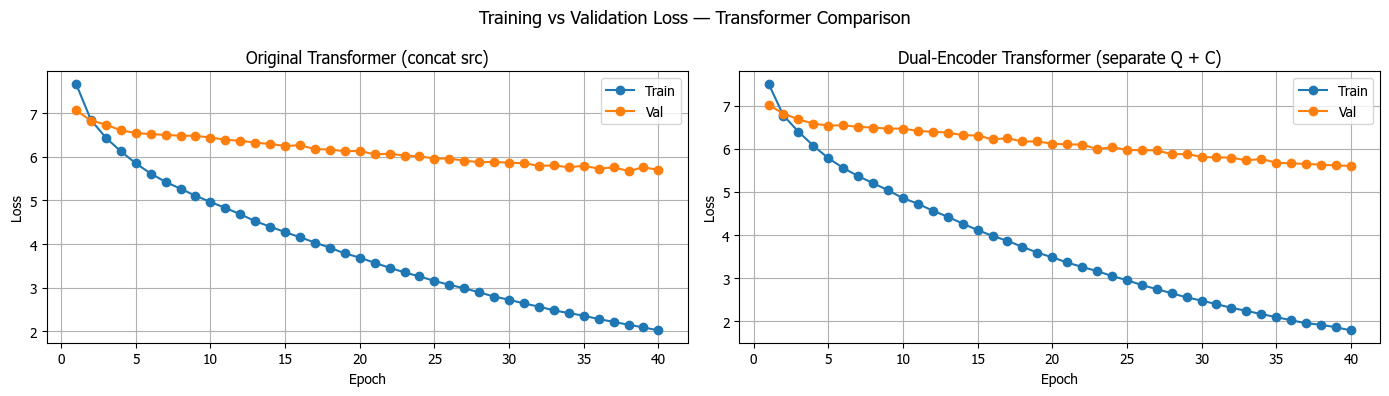

In [251]:
# ── Loss Curves: Original vs Dual-Encoder ───────────────────────────────────
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Original Transformer
orig_tl = [h['train_loss'] for h in history]
orig_vl = [h['val_loss']   for h in history]
axes[0].plot(range(1, len(orig_tl)+1), orig_tl, marker='o', label='Train')
axes[0].plot(range(1, len(orig_vl)+1), orig_vl, marker='o', label='Val')
axes[0].set_title('Original Transformer (concat src)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

# Dual-Encoder Transformer
dual_tl = [h['train_loss'] for h in dual_history]
dual_vl = [h['val_loss']   for h in dual_history]
axes[1].plot(range(1, len(dual_tl)+1), dual_tl, marker='o', label='Train')
axes[1].plot(range(1, len(dual_vl)+1), dual_vl, marker='o', label='Val')
axes[1].set_title('Dual-Encoder Transformer (separate Q + C)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.suptitle('Training vs Validation Loss — Transformer Comparison', fontsize=13)
plt.tight_layout()
plt.show()

## Analysis: Why Dual-Encoder Should Help (and Its Limits)

### What changes structurally

In the original Transformer, the single encoder applies self-attention over
the full 303-token concatenated sequence. Early attention heads must
simultaneously handle:
- Question-internal dependencies ("ما الحدث الذي جعل...")
- Context-internal dependencies (long Arabic sentences)
- Question-context cross-dependencies

The dual encoder separates the first two concerns. By the time fusion happens,
`q_repr` already encodes a compressed, self-consistent understanding of the
question, and `c_repr` encodes the context. The fusion cross-attention then has
a cleaner signal to work with.

### The fusion mechanism in plain terms

```python
fused = cross_attention(query=c_repr, key=q_repr, value=q_repr)
```

For each context position, the attention asks:
*"Which question tokens are most relevant to this part of the context?"*
This produces a context representation that is **question-conditioned** —
the same context would be encoded differently depending on what was asked.

### Remaining limitation

With 240 examples the fundamental data scarcity problem does not disappear.
The dual encoder adds parameters (two separate encoder layers + fusion layer)
relative to the original, which could make overfitting slightly worse.
The key question is whether the better inductive bias of separate encoding
outweighs the cost of extra parameters — which the loss curves will reveal.

In [252]:
# ── Best vs Worst Predictions by Token-F1 (Dual-Encoder) ────────────────────

@torch.no_grad()
def dual_show_best_worst(model, dataset_split, data_list, n_examples=10):
    model.eval()
    rows = []

    for i in range(len(dataset_split)):
        q_ids, c_ids, a_ids = dataset_split[i]

        out_ids   = dual_greedy_decode(model, q_ids.long(), c_ids.long())
        pred_text = decode_answer(out_ids)
        ref_text  = decode_answer([SOS_IDX] + a_ids.tolist() + [EOS_IDX])
        f1_score  = token_f1(pred_text, ref_text)

        if hasattr(dataset_split, 'indices'):
            orig_idx = dataset_split.indices[i]
            q_text   = data_list[orig_idx]['question']
            c_text   = data_list[orig_idx]['context']
            ref_raw  = data_list[orig_idx]['answer']
        else:
            q_text  = "[unavailable]"
            c_text  = "[unavailable]"
            ref_raw = ref_text

        rows.append({
            'i'        : i,
            'f1'       : f1_score,
            'question' : q_text,
            'context'  : c_text,
            'reference': ref_raw,
            'predicted': pred_text,
        })

    rows.sort(key=lambda x: x['f1'])
    worst = rows[:n_examples]
    best  = rows[-n_examples:][::-1]   # highest F1 first

    def print_row(r, rank_label):
        print("=" * 75)
        print(f"[{rank_label}]  sample={r['i']}  |  Token-F1: {r['f1']:.4f}")
        print(f"Q        : {r['question']}")
        print(f"Context  : {r['context'][:180]}{'...' if len(r['context']) > 180 else ''}")
        print(f"Reference: {r['reference']}")
        print(f"Predicted: {r['predicted']}")

    print("\n" + "█" * 75)
    print(f"  BEST {n_examples} PREDICTIONS  (highest Token-F1)")
    print("█" * 75)
    for rank, r in enumerate(best, 1):
        print_row(r, f"BEST #{rank}")
        
    print("\n" + "█" * 75)
    print(f"  WORST {n_examples} PREDICTIONS  (lowest Token-F1)")
    print("█" * 75)
    for rank, r in enumerate(worst, 1):
        print_row(r, f"WORST #{rank}")


    # Return for further use
    return worst, best

dual_worst, dual_best = dual_show_best_worst(
    dual_model, dual_val_ds, data, n_examples=10
)


███████████████████████████████████████████████████████████████████████████
  BEST 10 PREDICTIONS  (highest Token-F1)
███████████████████████████████████████████████████████████████████████████
[BEST #1]  sample=36  |  Token-F1: 1.0000
Q        : ما اسم الطائره التي تدور حولها الحلقه؟
Context  : اقدم لحضرتك فخر الطيران الامريكي الf-35. بس دي شكلها شبه اللي احنا عملناها قبل كدا! اه، بس التكنولوجيا اللي فيها سابقه بسنين ضوئيه.
Reference: f-35
Predicted: f 35
[BEST #2]  sample=29  |  Token-F1: 0.9333
Q        : ماذا حدث للساموراي في فتره ايدو؟
Context  : في فتره ايدو تحول الساموراي من محاربين الي موظفين بيروقراطيين.
Reference: تحول الساموراي من محاربين الي موظفين بيروقراطيين
Predicted: تحول الساموراي من محاربين الي موظفين بيروقراطيين الي
[BEST #3]  sample=13  |  Token-F1: 0.7692
Q        : ما العامل الجغرافي الذي جعل حدود روسيا عرضه للغزو المستمر؟
Context  : ليه ما زودتلناش اي حاجز منيع طبيعي... سلسله جبال شرق اوكرانيا.
Reference: غياب الحواجز الطبيعيه مثل الجبال
Predicted: غياب الحواجز 

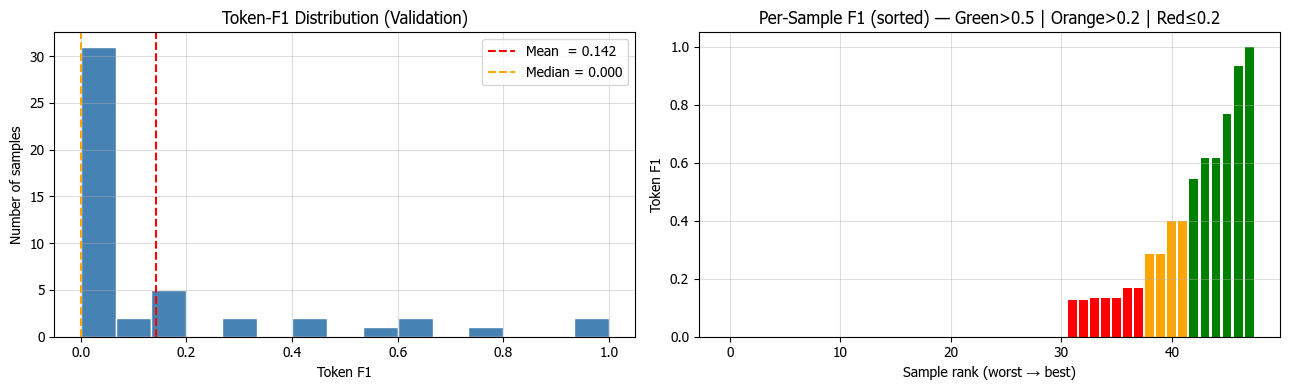


Validation set size : 48 samples
Mean  Token-F1      : 0.1424
Median Token-F1     : 0.0000
Std   Token-F1      : 0.2569
Max   Token-F1      : 1.0000
Min   Token-F1      : 0.0000

  Perfect (F1 = 1.0) :   1/48  █
  Good    (F1 > 0.5) :   6/48  ██████
  Partial (F1 > 0.2) :   4/48  ████
  Poor    (F1 ≤ 0.2) :  38/48  ██████████████████████████████████████
  Zero    (F1 = 0.0) :  31/48  ███████████████████████████████


In [253]:
# ── F1 Score Distribution across all validation samples ─────────────────────

@torch.no_grad()
def collect_all_f1(model, dataset_split, data_list):
    model.eval()
    f1_scores = []
    pred_texts = []
    ref_texts  = []

    for i in range(len(dataset_split)):
        q_ids, c_ids, a_ids = dataset_split[i]
        out_ids   = dual_greedy_decode(model, q_ids.long(), c_ids.long())
        pred_text = decode_answer(out_ids)
        ref_text  = decode_answer([SOS_IDX] + a_ids.tolist() + [EOS_IDX])
        f1        = token_f1(pred_text, ref_text)
        f1_scores.append(f1)
        pred_texts.append(pred_text)
        ref_texts.append(ref_text)

    return f1_scores, pred_texts, ref_texts

all_f1, all_preds, all_refs = collect_all_f1(dual_model, dual_val_ds, data)

# ── Distribution plot
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histogram
axes[0].hist(all_f1, bins=15, color='steelblue', edgecolor='white')
axes[0].axvline(np.mean(all_f1), color='red',    linestyle='--',
                label=f'Mean  = {np.mean(all_f1):.3f}')
axes[0].axvline(np.median(all_f1), color='orange', linestyle='--',
                label=f'Median = {np.median(all_f1):.3f}')
axes[0].set_title('Token-F1 Distribution (Validation)')
axes[0].set_xlabel('Token F1')
axes[0].set_ylabel('Number of samples')
axes[0].legend()
axes[0].grid(True, alpha=0.4)

# Sorted F1 per sample (shows how many are good vs bad)
sorted_f1 = sorted(all_f1)
axes[1].bar(range(len(sorted_f1)), sorted_f1, color=[
    'green' if f > 0.5 else 'orange' if f > 0.2 else 'red'
    for f in sorted_f1
])
axes[1].set_title('Per-Sample F1 (sorted) — Green>0.5 | Orange>0.2 | Red≤0.2')
axes[1].set_xlabel('Sample rank (worst → best)')
axes[1].set_ylabel('Token F1')
axes[1].grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

# ── Summary statistics
buckets = {
    'Perfect (F1 = 1.0)' : sum(1 for f in all_f1 if f == 1.0),
    'Good    (F1 > 0.5)' : sum(1 for f in all_f1 if f > 0.5),
    'Partial (F1 > 0.2)' : sum(1 for f in all_f1 if 0.2 < f <= 0.5),
    'Poor    (F1 ≤ 0.2)' : sum(1 for f in all_f1 if f <= 0.2),
    'Zero    (F1 = 0.0)' : sum(1 for f in all_f1 if f == 0.0),
}

n = len(all_f1)
print(f"\nValidation set size : {n} samples")
print(f"Mean  Token-F1      : {np.mean(all_f1):.4f}")
print(f"Median Token-F1     : {np.median(all_f1):.4f}")
print(f"Std   Token-F1      : {np.std(all_f1):.4f}")
print(f"Max   Token-F1      : {max(all_f1):.4f}")
print(f"Min   Token-F1      : {min(all_f1):.4f}")
print()
for label, count in buckets.items():
    bar = '█' * count
    print(f"  {label} : {count:>3}/{n}  {bar}")

In [254]:
# from sklearn.metrics import f1_score

# def evaluate_model(model, dataset):
#     predictions = []
#     references = []

#     for item in dataset:
#         pred = predict(model, item['question'], item['context'])
#         predictions.append(pred)
#         references.append(item['answer'])

#     exact_match = sum([p == r for p, r in zip(predictions, references)]) / len(references)

#     # simple token-level F1
#     def compute_f1(p, r):
#         p_tokens = p.split()
#         r_tokens = r.split()
#         common = set(p_tokens) & set(r_tokens)
#         if len(common) == 0:
#             return 0
#         precision = len(common) / len(p_tokens)
#         recall = len(common) / len(r_tokens)
#         return 2 * precision * recall / (precision + recall)

#     f1 = sum([compute_f1(p, r) for p, r in zip(predictions, references)]) / len(references)

#     return exact_match, f1

In [255]:
# print("RNN Model:", evaluate_model(model, val_ds))
# print("Transformer 1:", evaluate_model(trans_model, val_ds))
# print("Transformer 2:", evaluate_model(span_model, val_ds))
# print("Transformer 3:", evaluate_model(dual_model, val_ds))

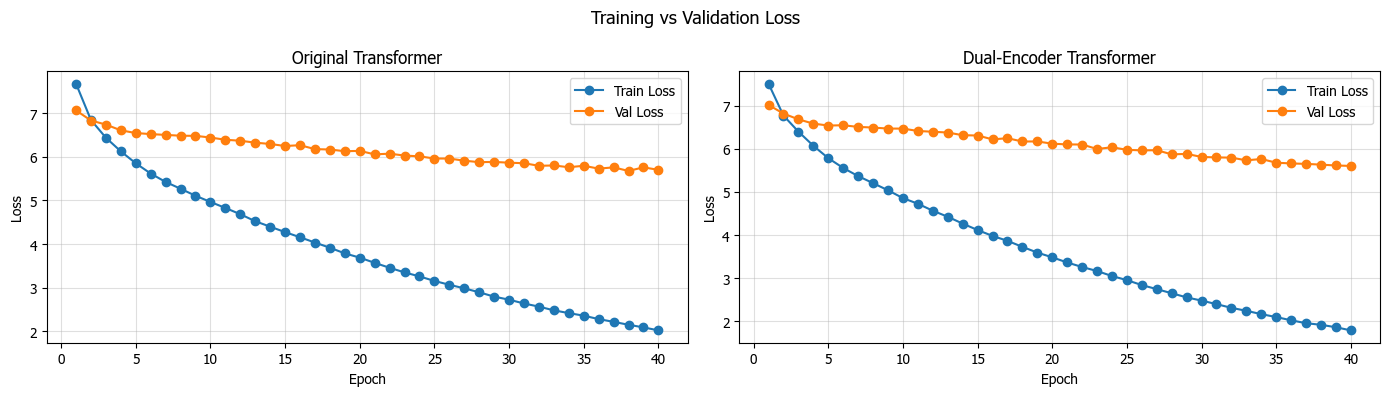

Original Transformer prediction:
تقديم بث اذاعي تسبب في ذعر جماهيري

Dual-Encoder Transformer prediction:
تمثيليه اذاعيه عن غزو فضائي يتغير وتوريث مهنه


In [256]:
# Well-defined inference functions for both transformer models.
# Each function takes raw question/context text and returns the final answer.

def original_transformer_inference(question, context, model=None):
    """Raw-input inference for the original Transformer model."""
    if model is None:
        model = globals().get("trans_model")
    if model is None:
        raise NameError("trans_model is not available in the current kernel.")
    return answer_question(model, question, context)


def dual_transformer_inference(question, context, model=None):
    """Raw-input inference for the dual-encoder Transformer model."""
    if model is None:
        model = globals().get("dual_model")
    if model is None:
        raise NameError("dual_model is not available in the current kernel.")
    return dual_answer_question(model, question, context)


# Training vs validation loss graphs for both transformers.
# This keeps the original and dual-encoder curves visible in one place.
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

orig_history = globals().get("history", [])
orig_train_loss = [h["train_loss"] for h in orig_history] if orig_history else []
orig_val_loss = [h["val_loss"] for h in orig_history] if orig_history else []
if orig_train_loss:
    orig_epochs = range(1, len(orig_train_loss) + 1)
    axes[0].plot(orig_epochs, orig_train_loss, marker="o", label="Train Loss")
    if orig_val_loss:
        axes[0].plot(orig_epochs, orig_val_loss, marker="o", label="Val Loss")
    axes[0].set_title("Original Transformer")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()
    axes[0].grid(True, alpha=0.4)
else:
    axes[0].set_title("Original Transformer")
    axes[0].text(0.5, 0.5, "history unavailable", ha="center", va="center")
    axes[0].axis("off")

dual_history = globals().get("dual_history", [])
dual_train_loss = [h["train_loss"] for h in dual_history] if dual_history else []
dual_val_loss = [h["val_loss"] for h in dual_history] if dual_history else []
if dual_train_loss:
    dual_epochs = range(1, len(dual_train_loss) + 1)
    axes[1].plot(dual_epochs, dual_train_loss, marker="o", label="Train Loss")
    if dual_val_loss:
        axes[1].plot(dual_epochs, dual_val_loss, marker="o", label="Val Loss")
    axes[1].set_title("Dual-Encoder Transformer")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Loss")
    axes[1].legend()
    axes[1].grid(True, alpha=0.4)
else:
    axes[1].set_title("Dual-Encoder Transformer")
    axes[1].text(0.5, 0.5, "dual_history unavailable", ha="center", va="center")
    axes[1].axis("off")

plt.suptitle("Training vs Validation Loss", fontsize=13)
plt.tight_layout()
plt.show()


# Quick raw-input demo for both models, if they are available in the current kernel.
sample_question = data[0]["question"] if data else ""
sample_context = data[0]["context"] if data else ""

print("Original Transformer prediction:")
try:
    print(original_transformer_inference(sample_question, sample_context))
except Exception as exc:
    print(f"skipped: {exc}")
print()
print("Dual-Encoder Transformer prediction:")
try:
    print(dual_transformer_inference(sample_question, sample_context))
except Exception as exc:
    print(f"skipped: {exc}")